### 1-1. midi 파일 전처리

In [3]:
from process import adjust_to_eighth_note, label_active_chord_by_onset, get_ready_with_lags

file_name = "Ryuichi_Sakamoto_-_hibari.mid"
adjusted_notes, tempo = adjust_to_eighth_note(file_name)

adn_1 = adjusted_notes[:2006]
adn_2 = adjusted_notes[2006:]

adn_1_real = adn_1[:-59]
adn_2_real = adn_2[59:]

adn_1_chord = label_active_chord_by_onset(adn_1_real) # 33*59
adn_2_chord = label_active_chord_by_onset(adn_2_real) # 32*59

adn_i = get_ready_with_lags(adn_1_chord, adn_2_chord)

1th instrument ending : index 2006
2th instrument ending : index 3953


c:\Users\82104\Developments\.venv\lib\site-packages\pretty_midi\pretty_midi.py:100: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


* 곡에서 반복되는 단위를 추출하고(module_notes), 각 시점에서 활성화된 음들을 모아(active_module) 화음 단위로 정제합니다.
* 화음에 대해 3가지 방식으로 딕셔너리를 만듭니다.

In [4]:
from process import (group_notes_with_duration_, notes_label_n_counts, 
                  chord_label_to_note_labels, transform_dict, chord_label_dict)

module_notes = adn_1_real[:59]
# module_chord = adn_1_chord[:32]
active_module = group_notes_with_duration_(module_notes)

notes_label, notes_counts = notes_label_n_counts(module_notes)
chord_label = chord_label_dict(active_module)

# notes = (pitch, duration)
notes_dict = chord_label_to_note_labels(chord_label, notes_label)
notes_dict['name'] = 'notes'

In [6]:
from process import simul_chord_lists
from util import simul_union_by_dict, get_correct_df

simul_whole_c = simul_chord_lists(adn_i[1][-1], adn_i[2][-1])
simul_notes = simul_union_by_dict(simul_whole_c, notes_dict)
hibari_notes_df = get_correct_df(notes_dict, simul_notes)

In [147]:
simul_notes

[{1, 6, 9, 15},
 {1, 6, 9, 19},
 {2, 7, 16, 20},
 {2, 7, 23},
 {3, 10, 18, 22},
 {3, 10, 21},
 {4, 10, 15, 19},
 {4, 10, 20},
 {6, 12, 16, 21},
 {6, 12, 19},
 {8, 14, 20},
 {8, 14, 17},
 {8, 14, 17},
 {8, 14, 17},
 {8, 14, 17},
 {8, 14, 17},
 {1, 6, 9, 15},
 {1, 6, 9, 19},
 {2, 7, 16, 20},
 {2, 7, 23},
 {3, 10, 18, 22},
 {3, 10, 21},
 {4, 10, 15, 19},
 {4, 10, 21},
 {6, 12, 16, 20},
 {6, 12, 18},
 {5, 11, 15, 19},
 {5, 11, 13},
 {5, 11, 13},
 {5, 11, 13},
 {5, 11, 13},
 {5, 11, 13},
 {1, 6, 9, 15},
 {1, 6, 9, 15, 19},
 {1, 2, 6, 7, 9, 16, 19, 20},
 {2, 7, 16, 20, 23},
 {2, 3, 7, 10, 18, 22, 23},
 {3, 10, 18, 21, 22},
 {3, 4, 10, 15, 19, 21},
 {4, 10, 15, 19, 20},
 {4, 6, 10, 12, 16, 20, 21},
 {6, 12, 16, 19, 21},
 {6, 8, 12, 14, 19, 20},
 {8, 14, 17, 20},
 {8, 14, 17},
 {8, 14, 17},
 {8, 14, 17},
 {8, 14, 17},
 {1, 6, 8, 9, 14, 15, 17},
 {1, 6, 9, 15, 19},
 {1, 2, 6, 7, 9, 16, 19, 20},
 {2, 7, 16, 20, 23},
 {2, 3, 7, 10, 18, 22, 23},
 {3, 10, 18, 21, 22},
 {3, 4, 10, 15, 19, 21},
 {4, 

In [11]:
from util import cycle_rBD_from_pkl

cycle_persistence = cycle_rBD_from_pkl('cycle_rBD_t_notes1_1e-4_0.0~1.5.pkl', dir="./pickle")

In [101]:
cycles_ends = dict()
for cycle in cycle_persistence.keys():
    cycle_ends = [cycle_persistence[cycle][0], cycle_persistence[cycle][-1]]
    cycles_ends[cycle] = cycle_ends

In [112]:
cycles_ends[(2, 20, 17, 6, 5, 18)]

[(0.0, 0.007692307692307693, 0.015384615384615385),
 (1.4999, 0.005814048135667325, 0.008620942337965079)]

In [113]:
cycles_ends2 = dict()
for cycle in cycles_ends.keys():
    birth_rate = cycles_ends[cycle][0][0]
    rate_persistence = cycles_ends[cycle][1][0] - cycles_ends[cycle][0][0] # rate persistence
    life_at_birth_rate = cycles_ends[cycle][0][2] - cycles_ends[cycle][0][1] # life at birth rate
    life_at_death_rate = cycles_ends[cycle][1][2] - cycles_ends[cycle][1][1] # life at death rate
    cycles_ends2[cycle] = [birth_rate, rate_persistence, life_at_birth_rate, life_at_death_rate]

In [116]:
cycles_ends2

{(2, 20, 17, 6, 5, 18): [0.0,
  1.4999,
  0.007692307692307693,
  0.002806894202297754],
 (0, 1, 2, 18, 5): [0.0, 0.0, 10000.992307692308, 10000.992307692308],
 (0, 15, 22, 1): [0.0, 0.0, 10000.992307692308, 10000.992307692308],
 (0, 5, 18, 19, 22, 1): [0.0, 0.0, 10000.992307692308, 10000.992307692308],
 (0, 15, 8, 18): [0.0001,
  1.2999,
  1.8933629562702808e-07,
  0.0012019230769230761],
 (0, 6, 9, 1): [0.0001, 1.2036, 1.8933629562702808e-07, 0.0011635407755827328],
 (0, 6, 17, 1): [0.0001, 1.4998, 9.466931292015368e-08, 0.0007118927811593668],
 (2, 9, 11, 5, 3): [0.0001,
  1.2036,
  1.4200309554537188e-07,
  0.0009162882701493858],
 (5, 11, 9, 18, 19): [0.0001,
  1.2036,
  3.786632707418122e-07,
  0.001954749121625546],
 (5, 11, 9, 15): [0.0001,
  1.2036,
  1.893374607384382e-07,
  0.0010429447172525044],
 (5, 16, 14, 18): [0.0001,
  0.9847,
  1.8930600645915285e-07,
  0.00041478244804139894],
 (0, 1, 9, 18, 5): [0.0001, 0.0023, 10000.992308047322, 10000.99231620359],
 (1, 9, 18, 5,

In [31]:
from util import label_cycle

cycle_labeled, length_counts_in_c, note_counts_in_c = label_cycle(cycle_persistence, transform_dict = notes_dict, log = True)

Cycle 길이별 개수:
Length 4: 27개
Length 5: 15개
Length 6: 6개

Component별 포함된 사이클 개수:
Note 6: 38개
Note 10: 38개
Note 1: 16개
Note 19: 15개
Note 2: 12개
Note 11: 11개
Note 4: 11개
Note 14: 10개
Note 12: 9개
Note 16: 9개
Note 7: 9개
Note 3: 8개
Note 23: 6개
Note 17: 6개
Note 15: 5개
Note 13: 5개
Note 20: 4개
Note 9: 4개
Note 18: 2개
Note 21: 1개

component label not in any cycle : {8, 5, 22}
where there are 23 components (notes_dict의 경우 인덱스가 1부터 시작합니다)


In [32]:
from util import get_scattered_cycles_df

# cycle_df 생성
cycles_weak = get_scattered_cycles_df(df = hibari_notes_df, cycle_labeled = cycle_labeled, binary = True)
cycles_strong = get_scattered_cycles_df(df = hibari_notes_df, cycle_labeled = cycle_labeled, binary = False)
cycles_strong.head(7)

,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
0,"{1, 6}","{1, 6}","{1, 6}",{1},"{1, 6}","{1, 6}","{1, 6, 15}",{1},"{1, 6}",{1},...,{6},{6},{6},{6},{6},{6},{6},"{6, 15}",{6},{9}
1,"{1, 19, 6}","{1, 19, 6}","{1, 6}",{1},"{1, 6}","{1, 19, 6}","{1, 19, 6}",{1},"{1, 6}",{1},...,"{19, 6}",{6},{6},{6},"{19, 6}",{6},{6},"{19, 6}","{19, 6}",{9}
2,{2},{2},{2},"{16, 2}",{2},"{2, 20}",{},"{2, 7}",{7},"{2, 7}",...,{20},{16},{},{},{},{},{},{},{},{16}
3,{2},{2},{2},"{2, 23}",{2},"{2, 23}",{},"{2, 7}",{7},"{2, 7}",...,{},{},{},{},{},{},{},{},{},{}
4,{3},{10},{10},{},{10},{},{10},{10},{10},{18},...,{10},{10},{10},{10},{10},{10},{10},{},{10},{10}
5,{3},{10},{10},{},{10},{},{10},{10},{10},{},...,{10},{10},{10},{10},{10},{10},{10},{},{10},{10}
6,{19},"{10, 19}",{10},{},{10},{19},"{10, 19, 15}",{10},{10},{},...,"{10, 19}",{10},{10},{10},"{10, 19}",{10},{10},"{19, 15}","{10, 19}",{10}


In [69]:
from util import evaluate_threshold, get_now

goal = 0.5
timestamp = get_now()
output_dir = f'scale_evaluation/{timestamp}'
for_overlap, for_scores, cycles_scaled_stat = evaluate_threshold(cycles_strong, cycle_labeled, goal, output_dir)

Working on 1th / 48 cycle : [1, 2, 3, 19, 6]
Working on 2th / 48 cycle : [1, 2, 10, 19, 6]
Working on 3th / 48 cycle : [1, 2, 10, 12, 6]
Working on 4th / 48 cycle : [1, 2, 23, 16]
Working on 5th / 48 cycle : [1, 6, 11, 10, 2]
Working on 6th / 48 cycle : [1, 6, 19, 20, 23, 2]
Working on 7th / 48 cycle : [1, 6, 19, 15, 10, 14]
Working on 8th / 48 cycle : [1, 7, 10, 2]
Working on 9th / 48 cycle : [1, 7, 10, 11, 6]
Working on 10th / 48 cycle : [1, 7, 18, 2]
Working on 11th / 48 cycle : [1, 14, 9, 16]
Working on 12th / 48 cycle : [1, 14, 10, 15, 17]
Working on 13th / 48 cycle : [1, 14, 10, 15, 19, 6]
Working on 14th / 48 cycle : [1, 16, 9, 19]
Working on 15th / 48 cycle : [1, 16, 23, 2]
Working on 16th / 48 cycle : [1, 20, 23, 2]
Working on 17th / 48 cycle : [2, 10, 19, 6, 16, 23]
Working on 18th / 48 cycle : [2, 10, 19, 20, 23]
Working on 19th / 48 cycle : [3, 4, 6, 7, 10]
Working on 20th / 48 cycle : [3, 10, 11, 6, 4]
Working on 21th / 48 cycle : [3, 10, 12, 6, 4]
Working on 22th / 48 cyc

In [66]:
# cycles_scaled_stat[:5]

In [34]:
from process import construct_overlap_df

overlapped_cycles = construct_overlap_df(for_overlap)

before_on = cycles_weak.sum().sum() / (46*1088)
after_on = overlapped_cycles.sum().sum() / (46*1088)
print(f"for hibari scores, ON ratio was originally {round( 100 * before_on, 2)}%")
print(f"which decreased to {round(100 * after_on, 2)}% after applying cyclewise scale\n")

print(f"it amounts to {round(100 * (1 - after_on / before_on), 2)}% reduction")
print(f"which is more than {round(100 * (1 - goal), 2)}% that i tried")

overlapped_cycles.head(5)

for hibari scores, ON ratio was originally 86.37%
which decreased to 50.94% after applying cyclewise scale

it amounts to 41.02% reduction
which is more than 40.0% that i tried


,0,1,2,3,4,5,6,7,8,9,...,38,39,40,41,42,43,44,45,46,47
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [44]:
# # overlapped_cycles.sum().value_counts() 
# column_sums = overlapped_cycles.sum()

# from collections import defaultdict

# # 합계 값을 key로 하고, 컬럼 이름을 value로 하는 딕셔너리 생성
# sum_to_columns = defaultdict(list)
# for col, sum_val in column_sums.items():
#     sum_to_columns[sum_val].append(col)

In [40]:
# # 합계 값이 같은 컬럼들만 출력 (리스트 길이가 1보다 큰 경우)
# multi_val = []
# for sum_val, columns in sum_to_columns.items():
#     if len(columns) > 1:
#         print(f"합계 {sum_val}: {columns}")
#         multi_val.append(sum_val)

In [43]:
# for sum_val in multi_val :
#     print(f"cycles whose on-value are the same as {sum_val}:")
#     for cycle_idx in sum_to_columns[sum_val]:
#         print(cycle_labeled[cycle_idx])
#     print("\n")

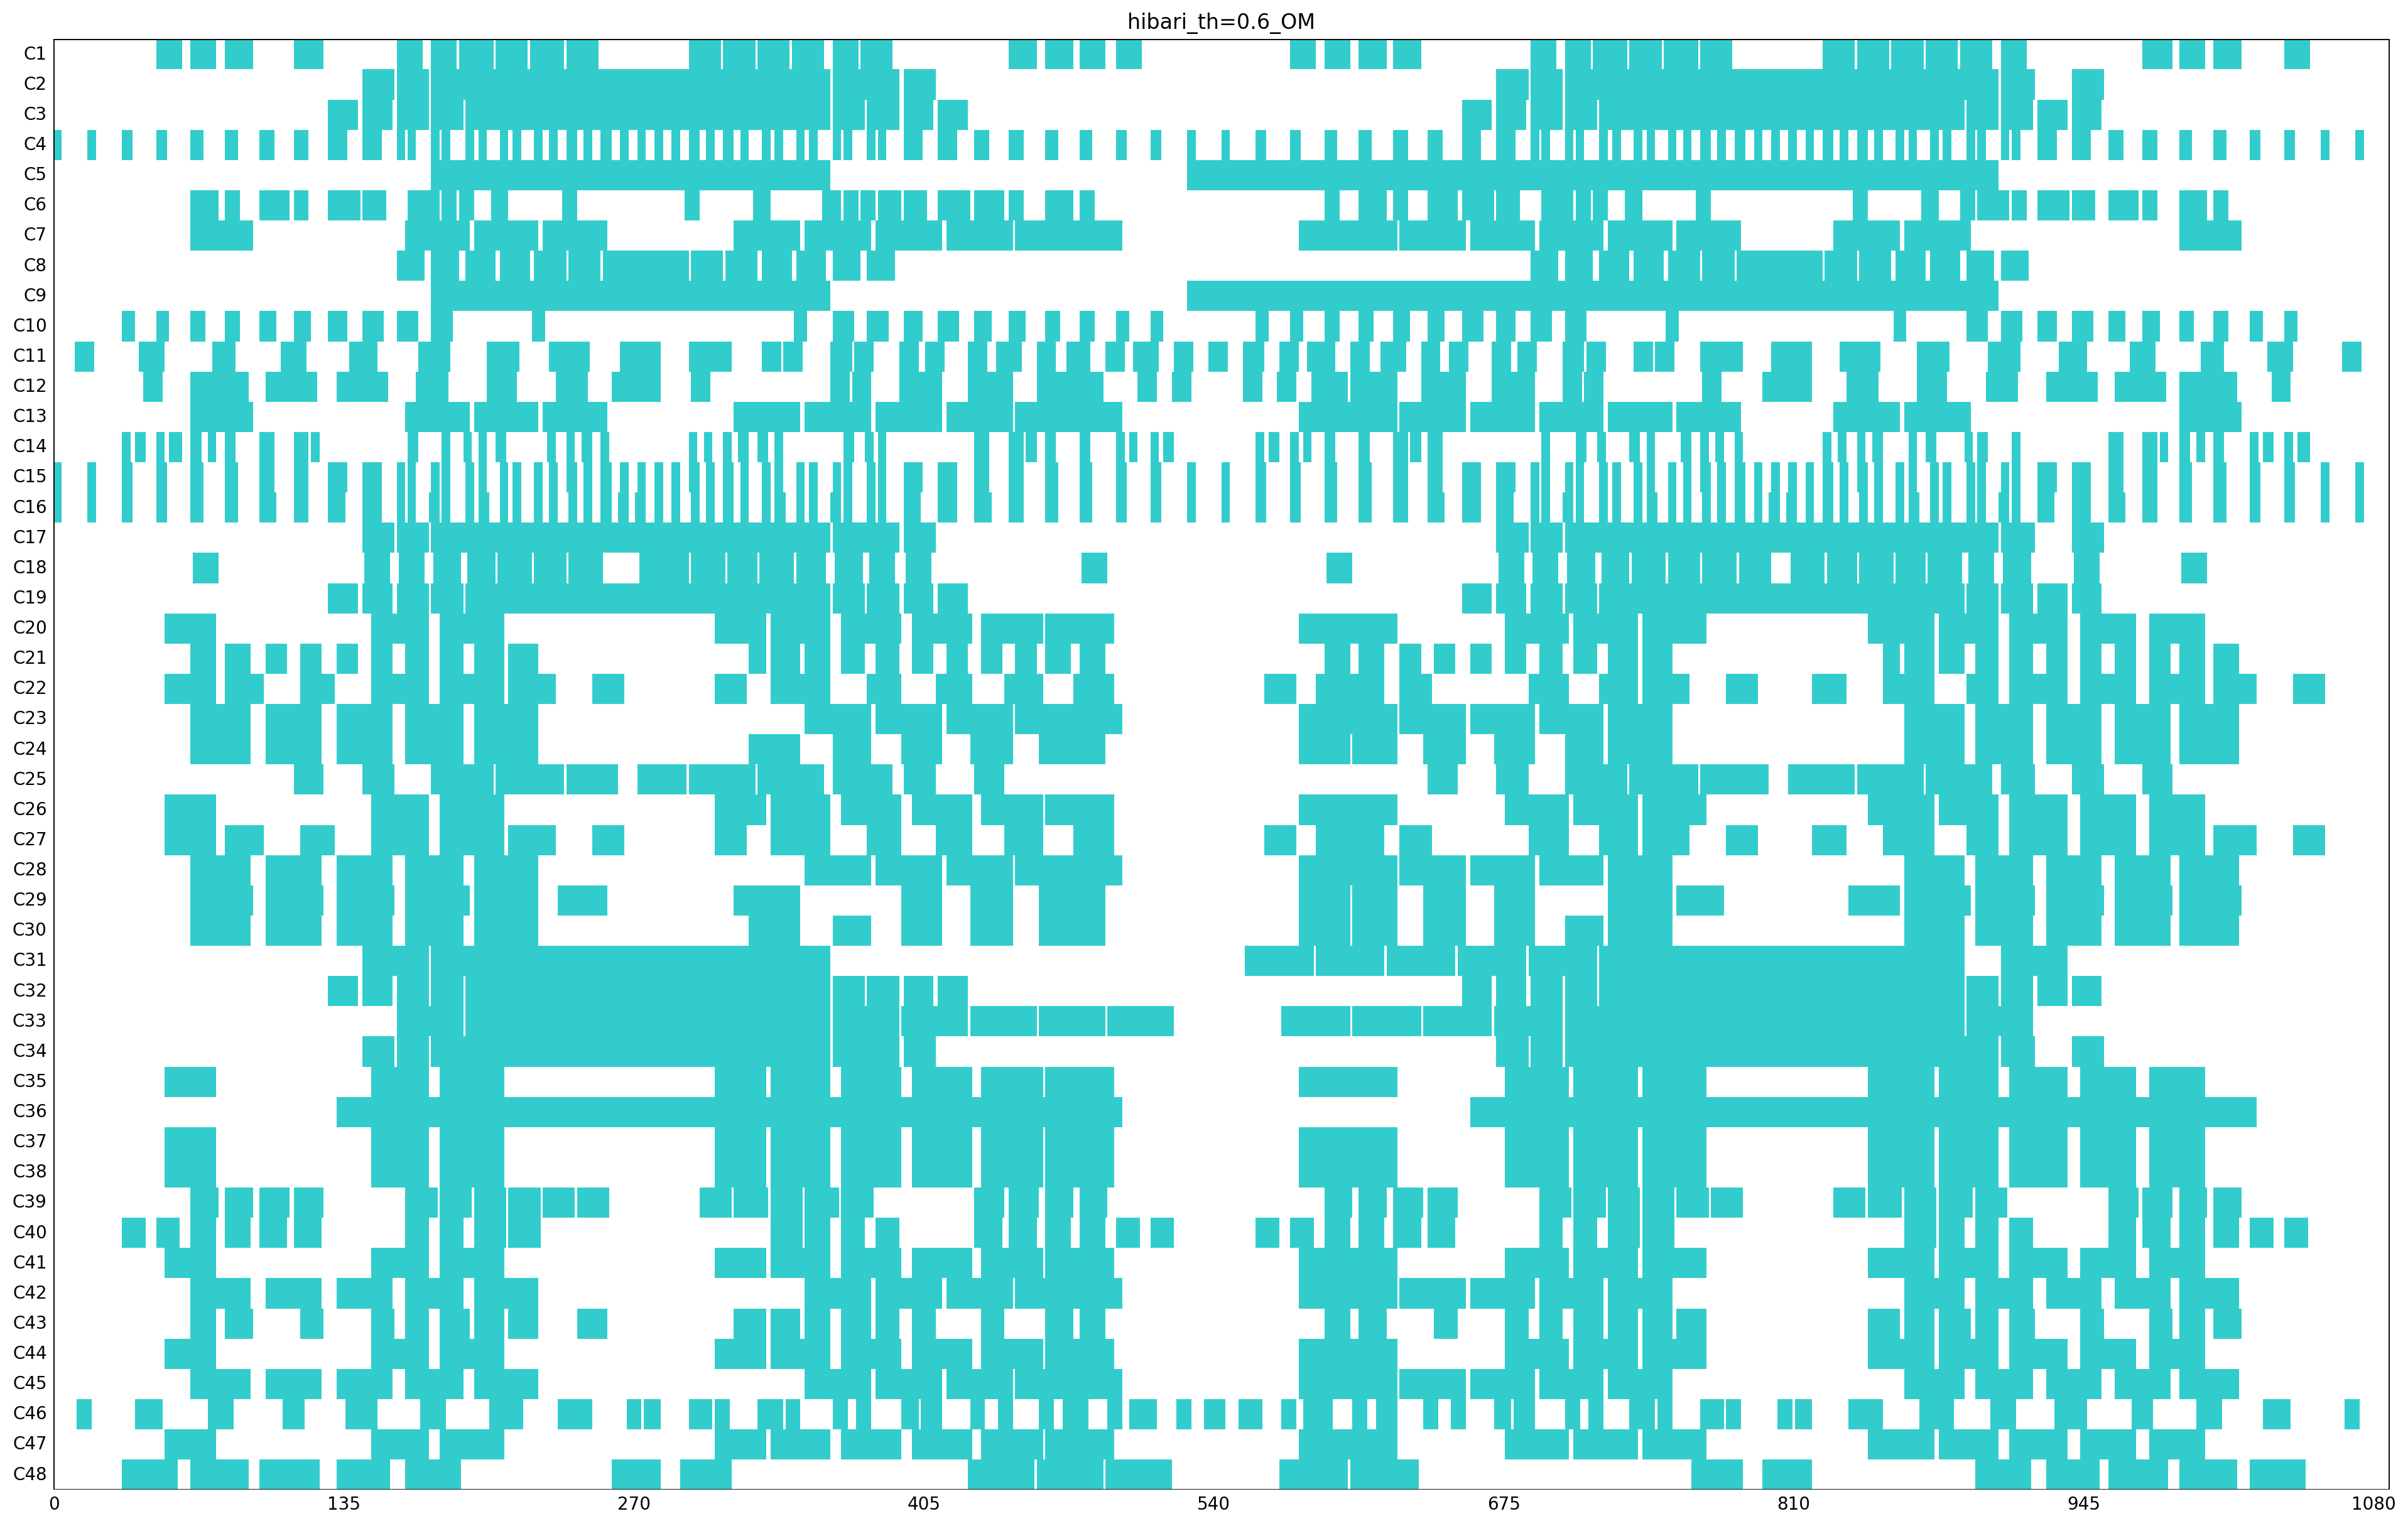

In [45]:
# 아래는 중첩행렬 시각화 함수입니다. 
from professor import plot_OM

songname = f'hibari_th={goal}'
plot_OM(overlapped_cycles, songname)

### 아니 왜 가운데에선 겹쳐지는 데 거의 비어있지... 거의 다 inter-based cycle이란 말인가?

* 3) 시간을 따라 순차적으로 진행하면서 중첩행렬의 원리를 반영한 음을 확률적으로 찾아낸다. 
## 확률적으로?? 아예 random하게 아니면 따르는 분포가 있나?

* 아예 480처럼 rearranged 케이스 말고 조금 차이가 나는 애들은 scale을 무시하고 조금 넣어줘야 할 것 같은데...
* 4, 23, 7도 포함해서...
* 일단 이렇게 해보고...
* 그렇게 micro intervention한 이후 scale reduction 비율이 원래 scale로 의도한 것을 준수하도록.

In [50]:
import numpy as np
overlap_matrix = overlapped_cycles.to_numpy() 
# (행, 열) = (시간, 사이클)이 되게 dataframe을 구성했으므로 교수님과 다르게 transpose해주지 않는다.

In [51]:
########################
# MAKE A NODE POOL & INTERSECTION
# 원곡의 노드들로 구성된 집합인 node pool을 정의하고 생성되는 곡은 이 node pool의 
# node를 이용하여 생성됩니다. 싸이클이 중첩됨은 두 싸이클이 서로 공유하는 node 가 
# 있다는 것을 의미하기 때문에 두 싸이클 집합의 교집합인 intersection 을 정의해 줍니다. 
########################
# 확률적 생성을 위해서 random 라이브러리를 불러 들입니다. 

from collections import Counter
num_modules = 65 
notes_counts_whole = {key: value * num_modules for key, value in notes_counts.items()}
counter = Counter(notes_counts_whole) # Counter 객체로 다시 변환
countersorted = dict(sorted(counter.items(), key = lambda x: x[1], reverse = True))
node_freq = list(countersorted.values())

nodelist = list(counter.keys()) # 추가된 부분

node_i = [nodelist.index(list(countersorted.keys())[i]) for i in range(len(nodelist))]
nn = len(node_i)
nsum = np.sum(node_freq)

* 왜 node_prob은 어디에도 쓰이지 않지?

In [52]:
import random

# NODE PROBABILITY ==================================
# 노드들의 빈도수 (중요도)를 반영하여 사용할 노드들의 확률을 계산하여 선택합니다. 
node_prob = np.zeros(nn)
for i in range(nn):
    ni = node_i[i]
    node_prob[ni] = node_freq[i]/nsum*100
    # print(f"{nodelist[ni]} appears {node_freq[i]} times") # countersorted와 비교하면 일치한다.

# 전체곡(L)에서 무작위로 index = (0, len(L)) 를 결정합니다.  ==================================
random_index = []
while len(random_index) <nsum:
    rand_index = random.randint(0,nsum-1)
    if rand_index not in set(random_index):
        random_index.append(rand_index)

In [53]:
c = list(cycle_labeled.values())

# 노드 풀을 정의합니다.  ==================================
node_pool = np.zeros(nsum)
index = -1
for i in range(nn):
    k = node_freq[i]
    for j in range(k):
        index = index + 1
        node_pool[random_index[index]] = node_i[i]
node_pool = [round(x) for x in node_pool]
all_cycle_set = list(set(c[i]) for i in range(len(c))) 

### all_cycle_set에서 Cycle 연결순서에 대한 고려가 깨지는데 괜찮을라나...

#### idea
* frequent_nodes에서 상위 5~8개를 기준치로 해서 빈도수 내림차순으로 리턴한다.
* 그럼 특정 시점에서 타건된 화음 수만큼 반복해서, 혹은 한 번에(그런 인자가 있다면) 뽑는다.
* 그리고 뽑힌 녀석들 중에 같은 것이 2개 이상이 되지 않도록 뽑는다

* 잠시만 근데 hibari_notes_df에서도 그냥 if any 메타로 빈도는 반영하지 않아서 inst 1, 2에서 동시에 활성화되어있던 녀석도 그냥 1로 나오는 거 아닌가? 

In [54]:
def frequent_nodes(all_cycle_set, keys):
  """
  주어진 키 목록에 해당하는 set들을 all_cycle_set 딕셔너리에서 가져와
  모든 set을 순회한 후, 전체 원소들의 등장 횟수를 계산하고,
  가장 높은 빈도수를 가진 원소들을 추출합니다.

  Args:
    all_cycle_set: (dict) 키는 set 레이블, 값은 set (집합) 객체인 딕셔너리.
    keys: (list) 순회할 all_cycle_set의 키 목록.

  Returns:
    (tuple) 튜플은 (전체 원소별 등장 횟수 딕셔너리, 가장 높은 빈도수를 가진 원소 리스트) 형식입니다.
  """

  elt_counts = {}
  for key in keys:
    elts = all_cycle_set[key]
    for elt in elts:
      if elt in elt_counts:
        elt_counts[elt] += 1
      else:
        elt_counts[elt] = 1

  max_count = 0
  most_frequent_elts = []
  for elt, count in elt_counts.items():
    if count > max_count:
      max_count = count
      most_frequent_elts = [elt]  # 새로운 최대 빈도수 발견 시 리스트 초기화
    elif count == max_count:
      most_frequent_elts.append(elt)

  return tuple(most_frequent_elts)


* (pkl, threshold) = ('cycle_rBD_t_notes1_1e-4_0.0~1.5.pkl', 0.8)에서 ALGO 1을 실행했을 때
* else문을 타는 경우(OM 상의 특정 시점에서 연주되는 사이클이 있는 경우)가 전체 1087번의 실행 중 중 1062번이었는데
* 그 중 node_intersect 함수 내에서 해당 사이클들의 공통 노드가 있는 경우는 62번이었습니다.
* 그러한 이유로 node_intersect를 수정해서 사용했습니다.

In [55]:
from process import get_note_by_label

# 싸이클을 미디로 변환합니다. 미디 음과 템포로 출력 = [[midi,tempo]]
def cycle_generate(ci, notes_label):
    """ 
    notes_label를 얻는 방법 :
      notes_label, notes_counts = notes_label_n_counts(module_notes)
       """
    cyclei = []
    for i in ci:
        midi, tempo = get_note_by_label(i, notes_label)
        cyclei.append([midi,tempo])
    return cyclei

########################################

all_cycle_number = []
for ci in c:
    all_cycle_number.extend(ci)

from music21 import duration, note, stream, meter

def node_intersect(overlap_matrix):

    if np.sum(overlap_matrix) == 0:
        err_message = 'no intersection error ......'
        print(err_message)
        return
    set_number = np.nonzero(overlap_matrix)

    y = frequent_nodes(all_cycle_set, set_number[0])
    return y
        
def node_union(overlap_matrix):

    if np.sum(overlap_matrix) == 0:
        err_message = 'no intersection error ......'
        print(err_message)
        return
    set_number = np.nonzero(overlap_matrix)
    n_s_n = len(set_number[0])

    for k in range(n_s_n):
        nl = set_number[0][k]
        if k ==0:
            y = all_cycle_set[nl]
        elif k >0:
            y = y.union(all_cycle_set[nl])
    return y

def choose_node_ts(z,time_signature,notes_label):

    node_current = cycle_generate([z], notes_label)
    int_midi_number=int(node_current[0][0])
    int_midi_duration=int(node_current[0][1])
    dur_hibari = int_midi_duration/2 # 8분음표를 한 박자로 했으므로 duration_in_quarter로 했을 때 0.5가 곱해지도록
    
    num_beats = time_signature.numerator
    beat_type = time_signature.denominator

    n1 = note.Note(int_midi_number)
    n1.duration=duration.Duration( dur_hibari * ( num_beats/beat_type ))

    return n1


* choose_node_ts에서 입력받는 z가 여러값이 될 수 있도록 하면
* cyclei = cycle_generate가 길이가 1보다 큰 list가 된다. 그러면 밑에서 특정 시점에 활성화된 음이 더 많아질 수 있다.
* 물론 데이터프레임의 형태로 변환해서 특정 노드 컬럼에서

In [56]:
# import numpy as np

# hibari_matrix = hibari_notes_df.to_numpy() 
# active_n = np.sum(hibari_matrix[3])
# active_n

### 왜 중간에 계속 반복되는 음이 너무 많은 거지??

In [ ]:
import os

# 아래는 최종적으로 미디음악을 생성하고 그것을 악보로 출력합니다. 
# 아래의 알고리즘음 다소 복잡합니다. 위의 논문을 참고하시기 바랍니다. 

s1 = stream.Stream()
# s1.clear()
# Set up a time signature (e.g., 4/4)
time_signature = meter.TimeSignature('4/4')
s1.append(time_signature)

#########
Lnew = []
#########

#under the assumption that the first one is 0
z = int(random.choice(tuple(node_pool)) )
# n1 = choose_node(z,nodelist,pitchlist,midilist)
print(f"first z is {z}")
n1 = choose_node_ts(z,time_signature,notes_label)
s1.append(n1)

#########
newnode = nodelist[z]
Lnew.append(newnode)
#########


for j in range (1,len(overlap_matrix)-1):
    flag_current = int(np.sum(overlap_matrix[j,:]))
    flag_next = int(np.sum(overlap_matrix[j+1,:]))
    flag_previous = int(np.sum(overlap_matrix[j-1,:]))

    if flag_current == 0:

        if flag_previous >0 and flag_next > 0:
            y_previous = node_union(overlap_matrix[j-1,:])
            y_next = node_union(overlap_matrix[j+1,:])
            y = y_previous.union(y_next)
            z = int(random.choice(tuple(node_pool)))
            while z in y:
                z = int(random.choice(tuple(node_pool)))

        elif flag_previous >0 and flag_next ==0 :
            y = node_union(overlap_matrix[j-1,:])
            z = int(random.choice(tuple(node_pool)))
            while z in y:
                z = int(random.choice(tuple(node_pool)))

        elif flag_previous == 0 and flag_next > 0:
            y = node_union(overlap_matrix[j+1,:])
            z = int(random.choice(tuple(node_pool)))
            while z in y:
                z = int(random.choice(tuple(node_pool)))


        elif flag_previous == 0 and flag_next == 0:
            z = int(random.choice(tuple(node_pool)))
        
        print(f"{j}th z is {z}, beep--")
        n1 = choose_node_ts(z,time_signature,notes_label)
        s1.append(n1)

        #########
        newnode = nodelist[z]
        Lnew.append(newnode)
        #########

    else:
        y = node_intersect(overlap_matrix[j,:])
        # print(y, j)
        z = int(random.choice(y))
        print(f"{j}th z is {z}")
        n1 = choose_node_ts(z,time_signature,notes_label)
        s1.append(n1)

        #########
        newnode = nodelist[z]
        Lnew.append(newnode)
        #########


#under the assumption that the last one is 0
z = int(random.choice(tuple(node_pool)) )
print(f"last z is {z}")
# n1 = choose_node(z,nodelist,pitchlist,midilist)
n1 = choose_node_ts(z,time_signature,notes_label)
s1.append(n1)

#########
newnode = nodelist[z]
Lnew.append(newnode)
#########

path = "./test_xml/" 
file_name = "output_from_"+songname+"_"+str(get_now())
musicxml_file = os.path.join(path, f'{file_name}.musicxml') 
s1.write('musicxml', fp=musicxml_file)
print(f"MusicXML 파일이 저장되었습니다: {musicxml_file}")

# fp=s1.write('midi',fp=path+"output_from"+songname+"_"+str(get_now())+".midi")
# fp2=s1.write('musicxml.pdf',path+"output_from"+songname+"_"+str(get_now())+".pdf")


first z is 4
1th z is 0
2th z is 22
3th z is 1
4th z is 3, beep--
5th z is 6, beep--
6th z is 2, beep--
7th z is 0, beep--
8th z is 9, beep--
9th z is 19, beep--
10th z is 15
11th z is 16
12th z is 0
13th z is 14
14th z is 0
15th z is 18
16th z is 0
17th z is 0
18th z is 0
19th z is 22
20th z is 16, beep--
21th z is 13, beep--
22th z is 0, beep--
23th z is 9, beep--
24th z is 0, beep--
25th z is 4, beep--
26th z is 1, beep--
27th z is 9, beep--
28th z is 9, beep--
29th z is 6, beep--
30th z is 5, beep--
31th z is 16, beep--
32th z is 15
33th z is 15
34th z is 15
35th z is 0
36th z is 15
37th z is 15
38th z is 15
39th z is 15
40th z is 15
41th z is 15
42th z is 15
43th z is 13
44th z is 13
45th z is 13
46th z is 13
47th z is 13
48th z is 0
49th z is 0
50th z is 0
51th z is 0
52th z is 9
53th z is 9
54th z is 5
55th z is 9
56th z is 9
57th z is 9
58th z is 5
59th z is 5
60th z is 9
61th z is 5
62th z is 5
63th z is 9
64th z is 9
65th z is 9
66th z is 9
67th z is 9
68th z is 9
69th z is 9

### 이렇게 1088이 되기를 바라는 게 아닌데..

In [61]:
len(Lnew)

1088

* 데이터프레임(hibari_)의 형태로 예측을 해서 그것을 바탕으로 length를 고려한 list[tuple] 형태로 정제해야 한다.
* 그런데 이때, 예를 들어 길이 5 짜리 note인데 df 상에서 5만큼 지속되지 않으면 어떡하지...?

## 교수님이 짜신 코드의 의도는 무엇이었고 왜 hibari에 대해서 하면 오류가 나는 걸까?

In [62]:
from process import get_flexible_pitches, get_hibari_notes

flexible_pitches = get_flexible_pitches(notes_counts, notes_label, log = True)
# hibari_notes = get_hibari_notes(adn_i[1][-1], adn_i[2][-1], notes_dict)

multilength pitch : its cardinality -> {69: 2, 60: 2, 64: 2, 57: 2, 65: 3}
labels of notes whose pitch is of multilength : [4, 5, 7, 8, 10, 11, 12, 13, 14, 16, 17]


In [90]:
from process import verify_scaled_cycles_by_scores

hibari_lists = [adn_1_real, adn_2_real]

In [ ]:
cycles_scaled = verify_scaled_cycles_by_scores(hibari_lists, cycle_labeled, for_scores, notes_label, flexible_pitches)

In [ ]:
# import process
# import importlib
# importlib.reload(process)

In [117]:
# Call the necessry libraries. Particularly torch for ML functions  
import math
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

#### scl을 변수로 받는데, 사이클 하나가 아니라 전체에 대해서 받는 건가?
#### node2idx가 그냥 등장한 순서대로 레이블링을 하고 이는 notes_dict에서 쓰인 레이블링 방식인 notes_label과 다른 데 괜찮을까? idx2node도 마찬가지

#### indexed_music에서 node를 music안에 있는 것으로 보는데 music안에 뭐가 있는 거지..?

## 음악을 다 생성한 다음에 node2idx로 idxing 해놓았던 것을 notes_label에 맞게 바꾸는 게 나을라나...

In [ ]:
import numpy as np

class Music:
    def __init__(self, cycles, scl, music=None, nodelist=None):
        self.cycles = cycles
        self.music = music
        self.nodelist = nodelist
        self.scl = scl

    def __repr__(self):
        return f'Music(length={self.length}, num_nodes={self.num_nodes}, num_cycles={self.num_cycles})'

    @property
    def length(self):
        return len(self.music)

    @property
    def num_nodes(self):
        return len(self.nodelist)

    @property
    def num_cycles(self):
        return len(self.cycles)

    @property
    def node2idx(self):
        return {node: idx for idx, node in enumerate(self.nodelist)}

    @property
    def idx2node(self):
        return {idx: node for idx, node in enumerate(self.nodelist)}

    @property
    def indexed_music(self):
        return np.array([self.node2idx[node] for node in self.music])

    def _split_music_by_beat(self):
        """
        (start, pitch, end) 튜플로 이루어진 음악 시퀀스를 8분음표 단위로 비트를 분할합니다.
        """
        col = []
        num_beats = math.ceil(max(end for _, _, end in self.music) / 8)

        for beat_index in range(1, num_beats + 1):
            current_beat = []

            for start, pitch, end in self.music:
                # start 값을 기준으로 비트 인덱스를 계산합니다.
                note_beat_index = math.floor(start / 8) + 1

                # 현재 비트 인덱스와 계산된 비트 인덱스가 같으면 추가합니다.
                if note_beat_index == beat_index:
                    current_beat.append((start, pitch, end))

            col.append(current_beat)

        return col
    
    # def _split_music_by_beat(self):
    #     col = []
    #     inx_s = 0
    #     sumleng = 0
    #     for i, node in enumerate(self.music):
    #         leng = round((node-int(node))*100,1)
    #         sumleng += leng
    #         if sumleng == 36:
    #             inx_e = i+1
    #             col.append(self.music[inx_s:inx_e])
    #             inx_s = i+1
    #             sumleng = 0

    #     col_inx = []
    #     for beat in col:
    #         col_inx.append(list(map(lambda x: self.node2idx[x], beat)))

    #     return col_inx

    def beat_start_indices(self):
        col_inx = self._split_music_by_beat()
        length_list = list(map(len, col_inx))

        cum_sum = 0
        start_indices = []
        for length in length_list:
            start_indices.append(cum_sum)
            cum_sum += length

        return start_indices

    def _node_overlap(self):
        matrix = []
        for cycle in self.cycles:
            row = []
            for node in self.music:
                inx = self.node2idx[node]
                if inx in cycle:
                    row.append(cycle.index(inx)+1)
                else:
                    row.append(0)
            matrix.append(row)

        for q in [scl-1]:
            mat = []
            for j, row in enumerate(matrix):
                new, leng = [], 0
                # construct new row
                for i, node in enumerate(row):
                    if node == 0:
                        if leng == 0:
                            new.append(0)
                        else:
                            if leng > q:
                                new += row[i-leng:i]+[0]
                            else:
                                new += [0]*leng+[0]
                            leng = 0
                    else:
                        leng += 1
                if leng != 0:
                    if leng > q:
                        new += row[len(row)-leng:]
                    else:
                        new += [0]*leng
                mat.append(new)

        return mat

    @property
    def overlap_matrix(self):
        mat = self._node_overlap()
        overlap_matrix = np.zeros((self.length, self.num_cycles))
        for i in range(self.length):
            for j in range(self.num_cycles):
                if mat[j][i] != 0:
                    overlap_matrix[i, j] = 1

        return overlap_matrix

    def load_music(self, fpath):
        self.music = np.loadtxt(fpath)

    def load_nodelist(self, fpath):
        self.nodelist = sorted(np.loadtxt(fpath))
#         self.nodelist = np.loadtxt(fpath)

In [144]:
# nodelist

In [146]:
# def node2idx(nodelist) :
#     return {node: idx for idx, node in enumerate(nodelist)}

# temp_dict = node2idx(nodelist)

# def idx2node(nodelist):
#     return {idx: node for idx, node in enumerate(nodelist)}

# temp_dict2 = idx2node(nodelist)

In [ ]:
# this is already computed in Algorithm 1
cycle_nodes = c
music = Music(cycles=cycle_nodes,scl=scl)
music.music = L
music.nodelist = nodelist
print(c)

In [151]:
for i, note in enumerate(adn_1_real[:5]):
    print(i, note)

0 (0, 67, 1)
1 (0, 52, 2)
2 (0, 59, 2)
3 (0, 62, 2)
4 (1, 72, 2)


### L에 대응되는 게 여기선 hibari_lists일라나?

In [ ]:
# L = [110.12, 110.04, 147.02, 196.12, 196.06, 98.12, 110.06, 98.06, 73.06, 196.12, 220.06, 110.06, 220.06, 220.12, 220.04, 147.02, 196.12, 196.06, 73.06, 196.06, 196.12, 196.04, 220.02, 110.12, 73.06, 110.06, 73.06, 196.06, 196.04, 147.02, 196.04, 220.02, 220.12, 196.06, 98.06, 147.06, 110.06, 98.04, 98.01, 110.01, 147.06, 196.12, 196.06, 98.06, 196.06, 220.02, 196.04, 196.04, 147.02, 196.06, 110.06, 147.06, 147.06, 110.12, 110.06, 98.06, 73.06, 196.12, 147.06, 73.06, 147.06, 196.06, 196.04, 147.02, 196.04, 220.02, 220.12, 196.06, 98.06, 147.06, 110.06, 98.04, 98.01, 110.01, 147.06, 196.12, 196.06, 98.06, 110.04, 147.02, 196.06, 196.04, 147.02, 196.06, 110.06, 147.06, 196.06, 147.04, 147.02, 147.06, 110.06, 110.06, 147.06, 110.12, 73.06, 110.06, 73.06, 147.04, 110.02, 98.04, 98.01, 110.01, 147.06, 196.06, 220.04, 196.02, 147.04, 147.02, 110.04, 110.01, 110.01, 147.04, 220.02, 196.12, 196.04, 220.02, 110.12, 73.06, 110.06, 73.06, 294.06, 294.06, 220.01, 294.04, 220.01, 110.02, 220.04, 220.06, 196.04, 220.02, 294.06, 294.04, 294.01, 220.01, 110.02, 220.04, 220.04, 196.02, 220.04, 294.02, 147.06, 147.06, 147.04, 196.02, 220.06, 220.06, 330.04, 294.02, 294.06, 220.01, 294.04, 220.01, 110.02, 220.04, 220.06, 220.04, 196.02, 98.12, 110.06, 98.06, 73.06, 220.12, 196.06, 98.06, 147.06, 110.12, 73.06, 110.04, 110.01, 110.01, 147.06, 196.06, 98.06, 147.06, 110.06, 98.04, 110.02, 147.06, 220.12, 196.04, 220.02, 196.06, 110.04, 147.02, 196.06, 196.04, 147.02, 196.06, 110.06, 147.06, 147.06, 110.06, 73.06, 110.06, 98.04, 110.02, 147.06, 110.12, 73.06, 110.06, 110.06, 110.01, 147.01, 110.04, 110.06, 98.04, 98.01, 110.01, 147.18, 73.12, 110.06, 98.06, 73.06]
# 교수님 코드에서의 L

In [184]:
import math

class MusicSplitter:
    def __init__(self, music):
        self.music = music

    def _split_music_by_beat(self):
        """
        (start, pitch, end) 튜플로 이루어진 음악 시퀀스를 8분음표 단위로 비트를 분할합니다.
        """
        col = []
        num_beats = math.ceil(max(end for _, _, end in self.music) / 8)

        for beat_index in range(1, num_beats + 1):
            current_beat = []

            for start, pitch, end in self.music:
                # start 값을 기준으로 비트 인덱스를 계산합니다.
                note_beat_index = math.floor(start / 8) + 1

                # 현재 비트 인덱스와 계산된 비트 인덱스가 같으면 추가합니다.
                if note_beat_index == beat_index:
                    current_beat.append((start, pitch, end))

            col.append(current_beat)

        return col

# 사용 예시:
music_sequence = hibari_lists[1][:159]

splitter = MusicSplitter(music_sequence)
split_music = splitter._split_music_by_beat()

# lens = 0
for i, beat in enumerate(split_music):
    print(f"Beat {i+1}, {i*8} : {beat}")
    lens += len(beat)

Beat 1, 0 : []
Beat 2, 8 : []
Beat 3, 16 : []
Beat 4, 24 : []
Beat 5, 32 : [(33, 67, 34), (33, 52, 35), (33, 59, 35), (33, 62, 35), (34, 72, 35), (35, 69, 36), (35, 74, 36), (35, 53, 37), (35, 60, 37), (36, 81, 37), (37, 71, 38), (37, 79, 38), (37, 55, 39), (37, 64, 39), (38, 76, 39), (39, 67, 40), (39, 72, 40), (39, 57, 41), (39, 64, 41)]
Beat 6, 40 : [(40, 74, 41), (41, 69, 42), (41, 76, 42), (41, 59, 43), (41, 65, 43), (42, 72, 43), (43, 74, 44), (43, 60, 49), (43, 65, 49), (44, 69, 49)]
Beat 7, 48 : [(49, 67, 50), (49, 52, 51), (49, 59, 51), (49, 62, 51), (50, 72, 51), (51, 69, 52), (51, 74, 52), (51, 53, 53), (51, 60, 53), (52, 81, 53), (53, 71, 54), (53, 79, 54), (53, 55, 55), (53, 64, 55), (54, 76, 55), (55, 67, 56), (55, 72, 56), (55, 57, 57), (55, 64, 57)]
Beat 8, 56 : [(56, 76, 57), (57, 69, 58), (57, 74, 58), (57, 59, 59), (57, 65, 59), (58, 71, 59), (59, 67, 60), (59, 72, 60), (59, 57, 65), (59, 64, 65), (60, 65, 65)]
Beat 9, 64 : [(66, 67, 67), (66, 52, 68), (66, 59, 68), 

In [189]:
split_music[:5]

[[],
 [],
 [],
 [],
 [(33, 67, 34),
  (33, 52, 35),
  (33, 59, 35),
  (33, 62, 35),
  (34, 72, 35),
  (35, 69, 36),
  (35, 74, 36),
  (35, 53, 37),
  (35, 60, 37),
  (36, 81, 37),
  (37, 71, 38),
  (37, 79, 38),
  (37, 55, 39),
  (37, 64, 39),
  (38, 76, 39),
  (39, 67, 40),
  (39, 72, 40),
  (39, 57, 41),
  (39, 64, 41)]]

In [186]:
notes_label

{(52, 2): 1,
 (53, 2): 2,
 (55, 2): 3,
 (57, 2): 4,
 (57, 6): 5,
 (59, 2): 6,
 (60, 2): 7,
 (60, 6): 8,
 (62, 2): 9,
 (64, 2): 10,
 (64, 6): 11,
 (65, 2): 12,
 (65, 5): 13,
 (65, 6): 14,
 (67, 1): 15,
 (69, 1): 16,
 (69, 5): 17,
 (71, 1): 18,
 (72, 1): 19,
 (74, 1): 20,
 (76, 1): 21,
 (79, 1): 22,
 (81, 1): 23}